#  M5 Demand Forecasting — Exploratory Data Analysis

> **Dataset:** M5 Walmart · 42,840 time series · 1,941 days  
> **Goal:** Understand the data structure, distributions, seasonality, and key patterns before modelling.

---

## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview](#2-overview)
3. [Hierarchy Exploration](#3-hierarchy)
4. [Sales Distribution & Zero Analysis](#4-zeros)
5. [Temporal Patterns — Seasonality](#5-seasonality)
6. [Event & Promotion Effects](#6-events)
7. [Price Analysis](#7-prices)
8. [SNAP Day Effects](#8-snap)
9. [Autocorrelation & Stationarity](#9-acf)
10. [Key EDA Takeaways](#10-takeaways)

## 1. Setup & Data Loading

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#0f1117',
    'axes.edgecolor':    '#2a2d3e',
    'axes.labelcolor':   '#c0c0c0',
    'xtick.color':       '#888',
    'ytick.color':       '#888',
    'text.color':        '#e0e0e0',
    'grid.color':        '#1e2130',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'font.family':       'monospace',
    'figure.dpi':        120,
})
ACCENT  = '#00d4ff'
ACCENT2 = '#f6ad55'
ACCENT3 = '#68d391'
PALETTE = [ACCENT, ACCENT2, ACCENT3, '#fc8181', '#b794f4', '#76e4f7']

print(' Libraries loaded')

 Libraries loaded


In [ ]:
#  Paths 
DATA_DIR = Path('../data/raw')   

# Load raw files
sales_eval = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')
sales_val  = pd.read_csv(DATA_DIR / 'sales_train_validation.csv')
calendar   = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])
prices     = pd.read_csv(DATA_DIR / 'sell_prices.csv')

print(f'sales_train_evaluation : {sales_eval.shape}')
print(f'sales_train_validation : {sales_val.shape}')
print(f'calendar               : {calendar.shape}')
print(f'sell_prices            : {prices.shape}')

sales_train_evaluation : (30490, 1947)
sales_train_validation : (30490, 1919)
calendar               : (1969, 14)
sell_prices            : (6841121, 4)


## 2. Dataset Overview

In [ ]:
# Basic info 
print('=== SALES (evaluation) ===')
print(sales_eval.head(3).to_string())
print(f'\nDate range: d_1 → d_{len([c for c in sales_eval.columns if c.startswith("d_")])}')
print(f'Calendar:   {calendar.date.min().date()} → {calendar.date.max().date()}')
print(f'\n=== CALENDAR ===')
print(calendar.head(3).to_string())
print(f'\n=== PRICES ===')
print(prices.head(3))

=== SALES (evaluation) ===
                              id        item_id    dept_id   cat_id store_id state_id  d_1  d_2  d_3  d_4  d_5  d_6  d_7  d_8  d_9  d_10  d_11  d_12  d_13  d_14  d_15  d_16  d_17  d_18  d_19  d_20  d_21  d_22  d_23  d_24  d_25  d_26  d_27  d_28  d_29  d_30  d_31  d_32  d_33  d_34  d_35  d_36  d_37  d_38  d_39  d_40  d_41  d_42  d_43  d_44  d_45  d_46  d_47  d_48  d_49  d_50  d_51  d_52  d_53  d_54  d_55  d_56  d_57  d_58  d_59  d_60  d_61  d_62  d_63  d_64  d_65  d_66  d_67  d_68  d_69  d_70  d_71  d_72  d_73  d_74  d_75  d_76  d_77  d_78  d_79  d_80  d_81  d_82  d_83  d_84  d_85  d_86  d_87  d_88  d_89  d_90  d_91  d_92  d_93  d_94  d_95  d_96  d_97  d_98  d_99  d_100  d_101  d_102  d_103  d_104  d_105  d_106  d_107  d_108  d_109  d_110  d_111  d_112  d_113  d_114  d_115  d_116  d_117  d_118  d_119  d_120  d_121  d_122  d_123  d_124  d_125  d_126  d_127  d_128  d_129  d_130  d_131  d_132  d_133  d_134  d_135  d_136  d_137  d_138  d_139  d_140  d_141  d_142  

In [ ]:
# Key counts 
id_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']
d_cols  = [c for c in sales_eval.columns if c.startswith('d_')]

stats = {
    'Total series':      len(sales_eval),
    'Unique items':      sales_eval['item_id'].nunique(),
    'Unique stores':     sales_eval['store_id'].nunique(),
    'Unique depts':      sales_eval['dept_id'].nunique(),
    'Unique categories': sales_eval['cat_id'].nunique(),
    'States':            sales_eval['state_id'].nunique(),
    'Days in eval':      len(d_cols),
    'Total observations':f"{len(sales_eval) * len(d_cols):,}",
}
for k, v in stats.items():
    print(f'  {k:<25} {v}')

  Total series              30490
  Unique items              3049
  Unique stores             10
  Unique depts              7
  Unique categories         3
  States                    3
  Days in eval              1941
  Total observations        59,181,090


## 3. Hierarchy Exploration

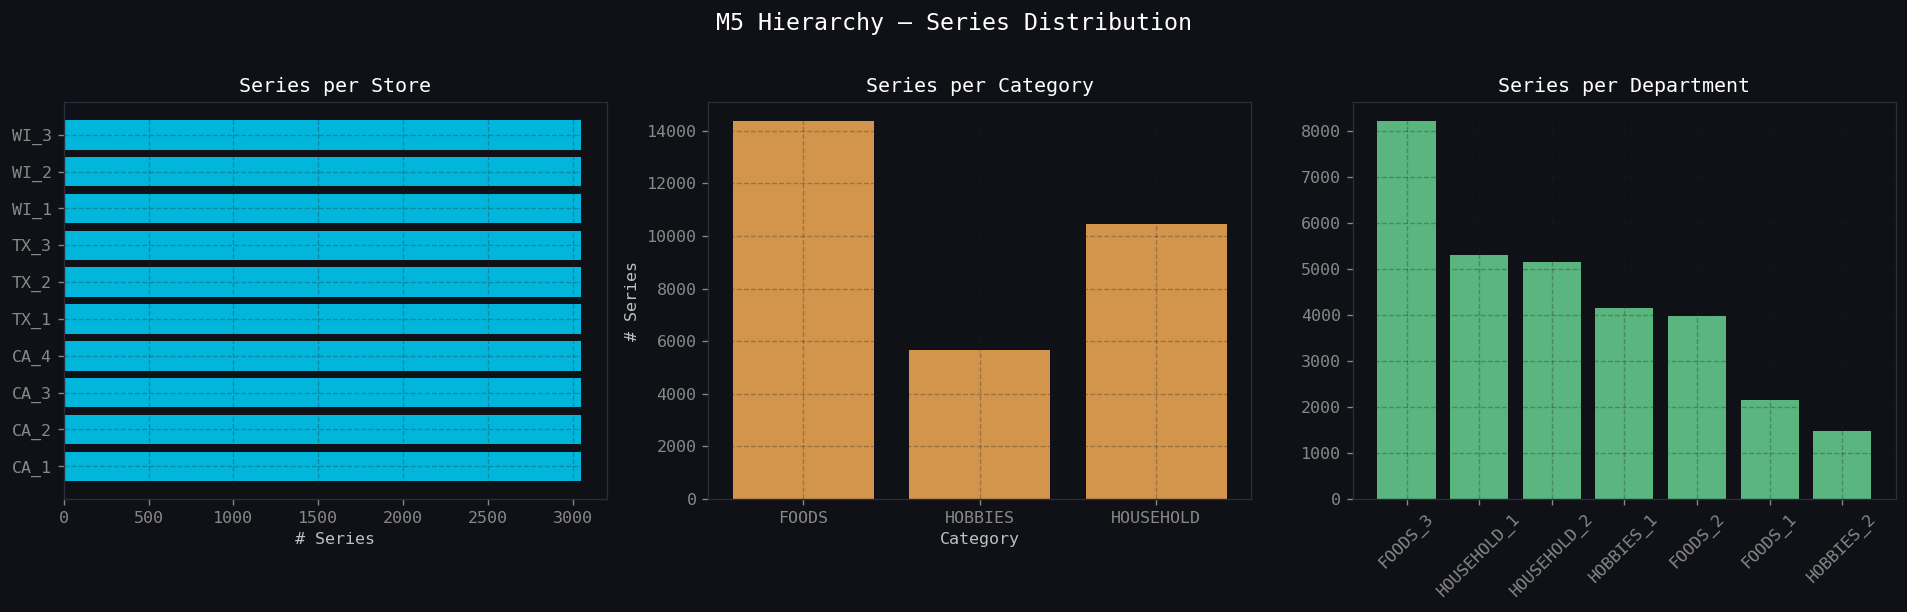

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('M5 Hierarchy — Series Distribution', fontsize=14, color='white', y=1.01)

# Series per store
store_counts = sales_eval.groupby('store_id').size().sort_values(ascending=True)
axes[0].barh(store_counts.index, store_counts.values, color=ACCENT, alpha=0.85)
axes[0].set_title('Series per Store', color='white')
axes[0].set_xlabel('# Series')

# Series per category
cat_counts = sales_eval.groupby('cat_id').size()
axes[1].bar(cat_counts.index, cat_counts.values, color=ACCENT2, alpha=0.85)
axes[1].set_title('Series per Category', color='white')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('# Series')

# Series per dept
dept_counts = sales_eval.groupby('dept_id').size().sort_values(ascending=False)
axes[2].bar(dept_counts.index, dept_counts.values, color=ACCENT3, alpha=0.85)
axes[2].set_title('Series per Department', color='white')
axes[2].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

## 4. Sales Distribution & Zero Analysis

In [ ]:
#  Melt to long format for analysis
SAMPLE_STORES = ['CA_1', 'TX_1', 'WI_1']   # one per state
sample = sales_eval[sales_eval['store_id'].isin(SAMPLE_STORES)].copy()

long = sample[id_cols + d_cols].melt(
    id_vars=id_cols, value_vars=d_cols,
    var_name='d', value_name='sales'
)
long = long.merge(calendar[['d','date','wm_yr_wk']], on='d', how='left')
print(f'Long format shape: {long.shape}')
print(f'Zero sales rows:   {(long.sales == 0).sum():,} ({100*(long.sales==0).mean():.1f}%)')

Long format shape: (17754327, 10)
Zero sales rows:   12,027,206 (67.7%)


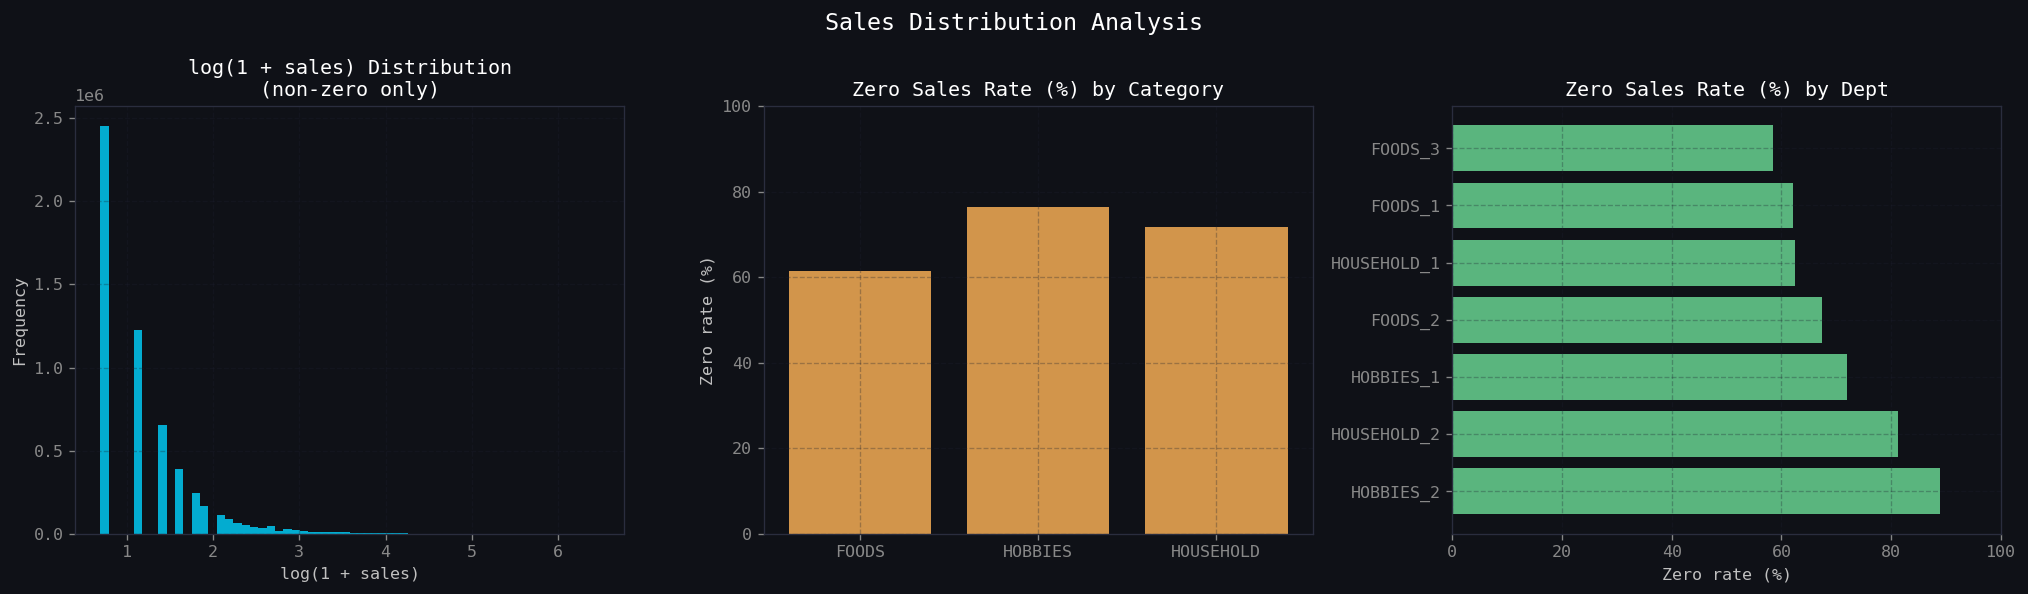

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Sales Distribution Analysis', fontsize=14, color='white')

# Overall distribution (log scale)
nonzero = long[long.sales > 0]['sales']
axes[0].hist(np.log1p(nonzero), bins=60, color=ACCENT, alpha=0.8, edgecolor='none')
axes[0].set_title('log(1 + sales) Distribution\n(non-zero only)', color='white')
axes[0].set_xlabel('log(1 + sales)')
axes[0].set_ylabel('Frequency')

# Zero rate per category
zero_by_cat = long.groupby('cat_id')['sales'].apply(lambda x: (x==0).mean() * 100)
axes[1].bar(zero_by_cat.index, zero_by_cat.values, color=ACCENT2, alpha=0.85)
axes[1].set_title('Zero Sales Rate (%) by Category', color='white')
axes[1].set_ylabel('Zero rate (%)')
axes[1].set_ylim(0, 100)

# Zero rate per dept
zero_by_dept = long.groupby('dept_id')['sales'].apply(lambda x: (x==0).mean() * 100).sort_values(ascending=False)
axes[2].barh(zero_by_dept.index, zero_by_dept.values, color=ACCENT3, alpha=0.85)
axes[2].set_title('Zero Sales Rate (%) by Dept', color='white')
axes[2].set_xlabel('Zero rate (%)')
axes[2].set_xlim(0, 100)

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

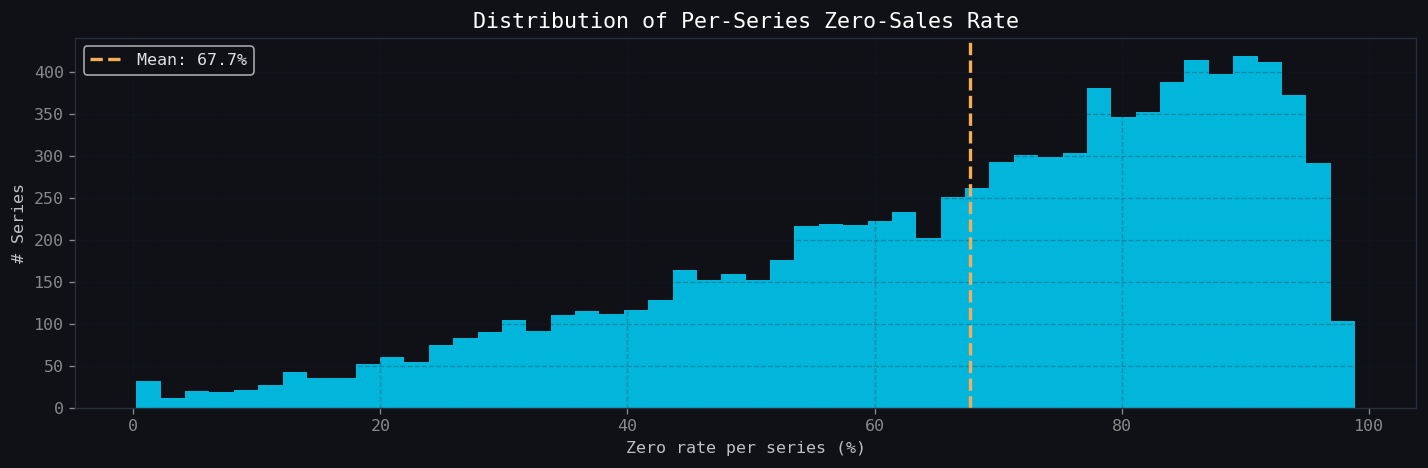


Series with >50% zero days (intermittent demand): 7200 (78.7%)


In [ ]:
# Per-series intermittency analysis 
zero_rate_per_series = (
    long.groupby('id')['sales']
    .apply(lambda x: (x == 0).mean())
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(zero_rate_per_series * 100, bins=50, color=ACCENT, alpha=0.85, edgecolor='none')
ax.axvline(zero_rate_per_series.mean() * 100, color=ACCENT2, linestyle='--', lw=2,
           label=f'Mean: {zero_rate_per_series.mean()*100:.1f}%')
ax.set_title('Distribution of Per-Series Zero-Sales Rate', color='white', fontsize=13)
ax.set_xlabel('Zero rate per series (%)')
ax.set_ylabel('# Series')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

intermittent = (zero_rate_per_series > 0.5).sum()
print(f'\nSeries with >50% zero days (intermittent demand): {intermittent} ({100*intermittent/len(zero_rate_per_series):.1f}%)')

## 5. Temporal Patterns — Seasonality

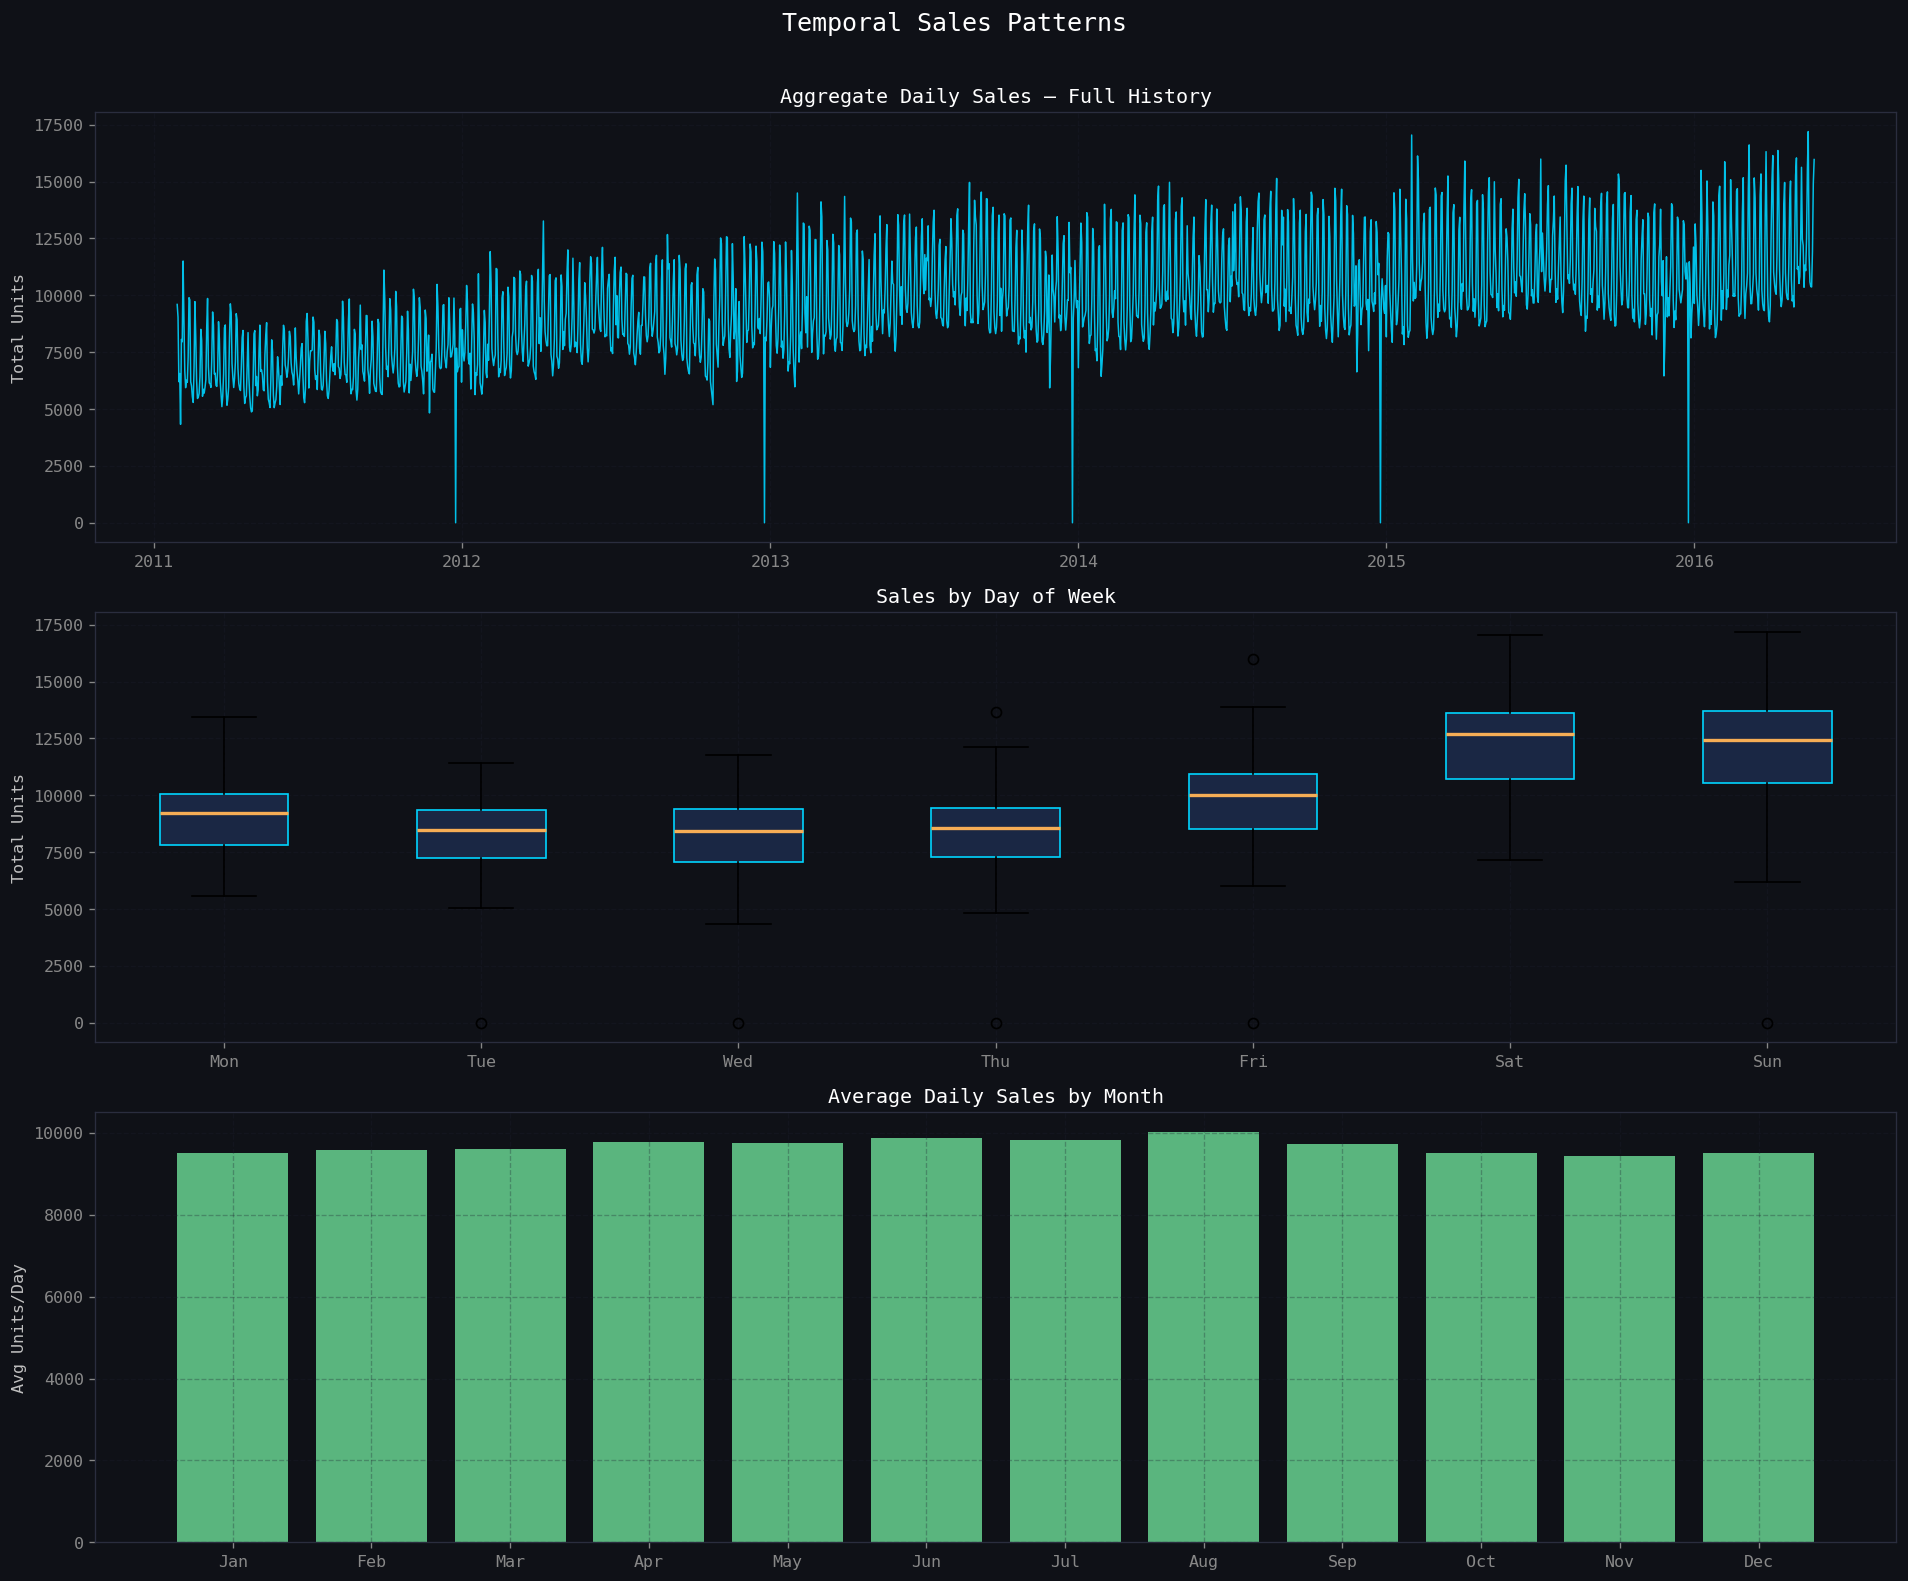

In [ ]:
# Aggregate daily sales 
daily = (
    long.groupby('date')['sales']
    .sum()
    .reset_index()
    .rename(columns={'sales': 'total_sales'})
)
daily['dow']   = daily['date'].dt.dayofweek
daily['month'] = daily['date'].dt.month
daily['year']  = daily['date'].dt.year
daily['week']  = daily['date'].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('Temporal Sales Patterns', fontsize=15, color='white', y=1.01)

# Full time series 
axes[0].plot(daily['date'], daily['total_sales'], color=ACCENT, lw=0.9, alpha=0.9)
axes[0].set_title('Aggregate Daily Sales — Full History', color='white')
axes[0].set_ylabel('Total Units')

# Day-of-week boxplot
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_data = [daily[daily['dow'] == i]['total_sales'].values for i in range(7)]
bp = axes[1].boxplot(dow_data, patch_artist=True, medianprops=dict(color=ACCENT2, lw=2))
for patch, color in zip(bp['boxes'], [ACCENT]*7):
    patch.set_facecolor('#1a2744')
    patch.set_edgecolor(ACCENT)
axes[1].set_xticklabels(dow_labels)
axes[1].set_title('Sales by Day of Week', color='white')
axes[1].set_ylabel('Total Units')

# Monthly average
month_avg = daily.groupby('month')['total_sales'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_labels, month_avg.values, color=ACCENT3, alpha=0.85)
axes[2].set_title('Average Daily Sales by Month', color='white')
axes[2].set_ylabel('Avg Units/Day')

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

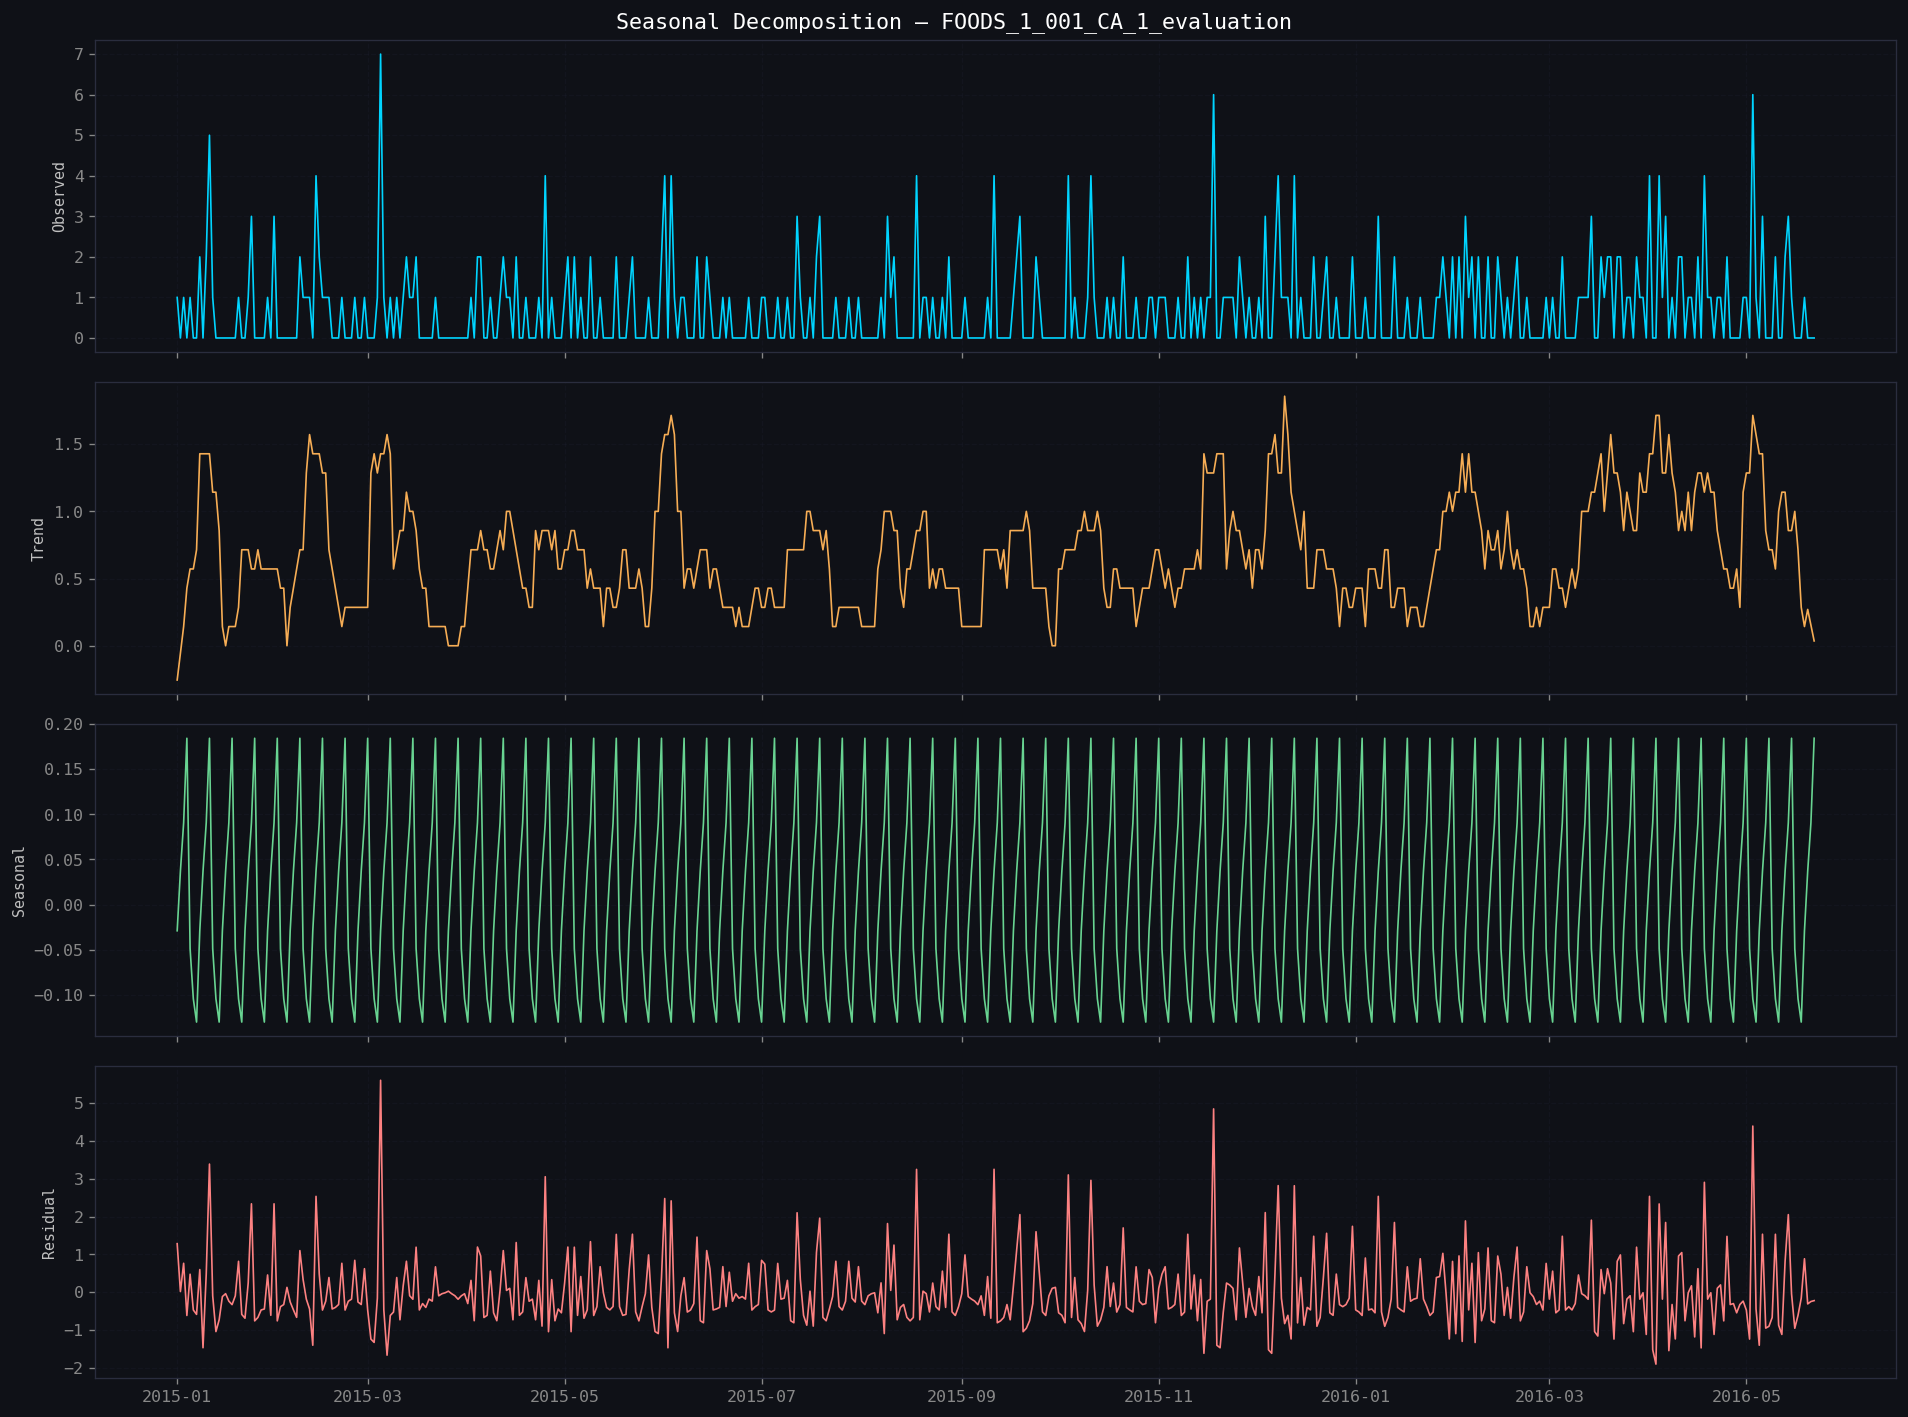

In [ ]:
#  STL Decomposition on one representative series
# Picked a high-volume FOODS series for clean decomposition
example_id = sales_eval[sales_eval['cat_id'] == 'FOODS'].iloc[0]['id']
series = (
    sales_eval[sales_eval['id'] == example_id][d_cols]
    .values.flatten()
    .astype(float)
)
series_dates = calendar.set_index('d').loc[d_cols, 'date']
s = pd.Series(series, index=pd.to_datetime(series_dates.values))

# Used last 2 years for cleaner decomp
s2 = s[s.index >= '2015-01-01']
decomp = seasonal_decompose(s2, model='additive', period=7, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle(f'Seasonal Decomposition — {example_id}', color='white', fontsize=13)

components = [
    (s2,              'Observed',  ACCENT),
    (decomp.trend,    'Trend',     ACCENT2),
    (decomp.seasonal, 'Seasonal',  ACCENT3),
    (decomp.resid,    'Residual',  '#fc8181'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, lw=1)
    ax.set_ylabel(title, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

## 6. Event & Promotion Effects

In [ ]:
#  Merge events into daily aggregate
cal_slim = calendar[['date','event_name_1','event_type_1','event_name_2','event_type_2']].copy()
daily_ev = daily.merge(cal_slim, on='date', how='left')

daily_ev['has_event'] = daily_ev['event_name_1'].notna()
event_lift = daily_ev.groupby('has_event')['total_sales'].describe()
print('Sales stats — event vs non-event days:')
print(event_lift.to_string())

Sales stats — event vs non-event days:
            count         mean          std     min     25%     50%      75%      max
has_event                                                                            
False      1783.0  9716.153674  2362.851988  4326.0  8123.0  9423.0  11039.5  17195.0
True        158.0  9257.436709  2841.020619     0.0  7854.5  9419.0  10943.0  16037.0


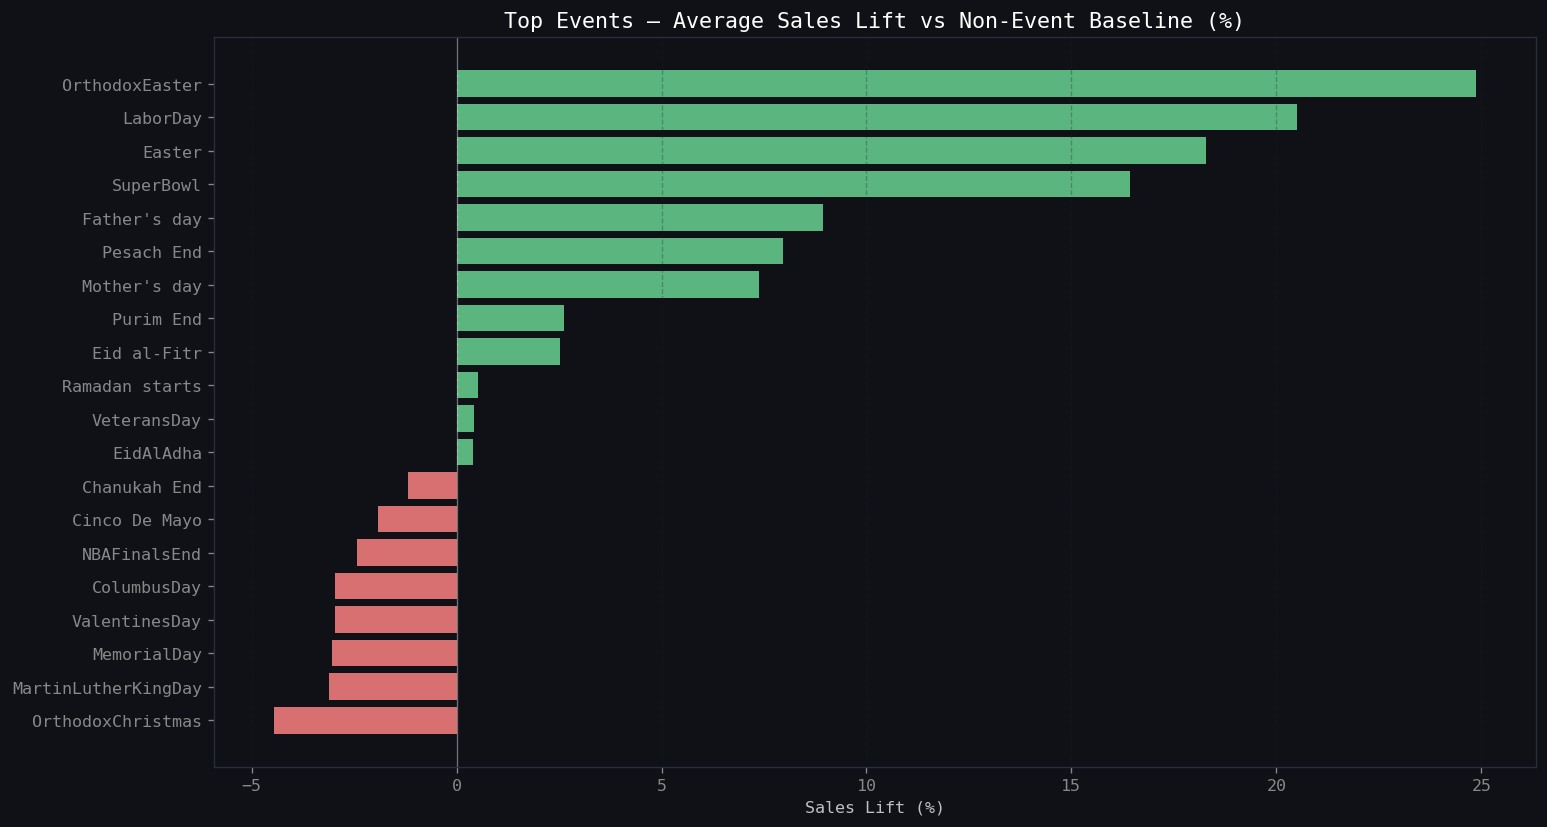

In [ ]:
# Top events by average sales lift 
baseline = daily_ev[~daily_ev['has_event']]['total_sales'].mean()

event_impact = (
    daily_ev[daily_ev['has_event']]
    .groupby('event_name_1')['total_sales']
    .mean()
    .apply(lambda x: (x / baseline - 1) * 100)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 7))
colors = [ACCENT3 if v >= 0 else '#fc8181' for v in event_impact.values]
ax.barh(event_impact.index[::-1], event_impact.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0, color='white', lw=0.8, alpha=0.4)
ax.set_title('Top Events — Average Sales Lift vs Non-Event Baseline (%)', color='white', fontsize=13)
ax.set_xlabel('Sales Lift (%)')
ax.grid(True, alpha=0.3, axis='x')
ax.set_facecolor('#0f1117')
plt.tight_layout()
plt.show()

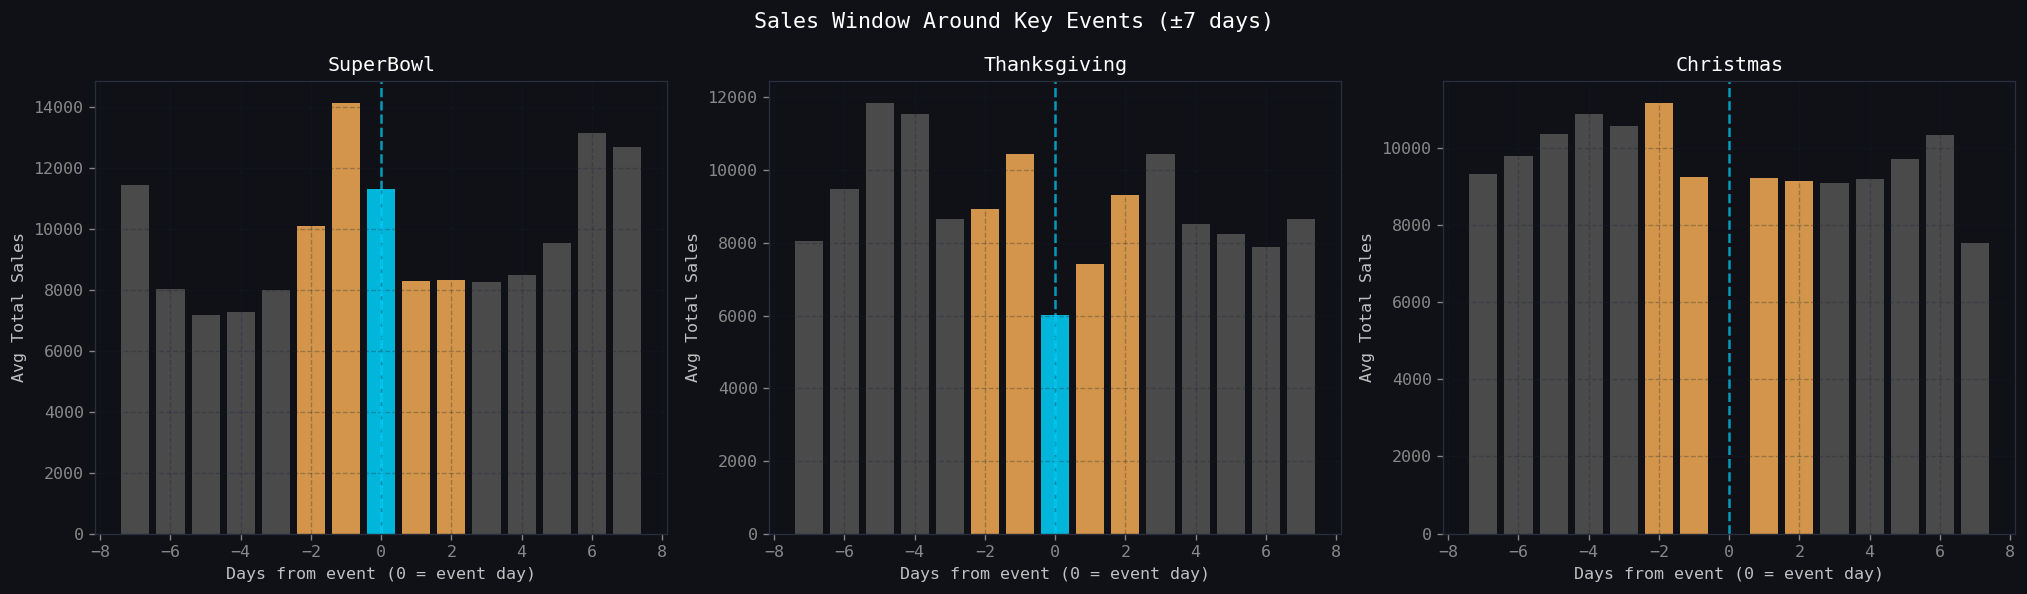

In [ ]:
# Pre / during / post event window effect (e.g. SuperBowl) 
def event_window_effect(event_name, window=7):
    """Shows sales in a ±window day range around an event."""
    ev_dates = daily_ev[daily_ev['event_name_1'] == event_name]['date'].values
    if len(ev_dates) == 0:
        return None

    rows = []
    for ev_date in ev_dates:
        for offset in range(-window, window + 1):
            check_date = pd.Timestamp(ev_date) + pd.Timedelta(days=offset)
            row = daily_ev[daily_ev['date'] == check_date]
            if not row.empty:
                rows.append({'offset': offset, 'sales': row['total_sales'].values[0]})

    df = pd.DataFrame(rows)
    return df.groupby('offset')['sales'].mean()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Sales Window Around Key Events (±7 days)', color='white', fontsize=13)

for ax, event in zip(axes, ['SuperBowl', 'Thanksgiving', 'Christmas']):
    w = event_window_effect(event)
    if w is not None:
        colors_w = [ACCENT if i == 0 else ACCENT2 if abs(i) <= 2 else '#555' for i in w.index]
        ax.bar(w.index, w.values, color=colors_w, alpha=0.85)
        ax.axvline(0, color=ACCENT, lw=1.5, linestyle='--', alpha=0.7)
        ax.set_title(event, color='white')
        ax.set_xlabel('Days from event (0 = event day)')
        ax.set_ylabel('Avg Total Sales')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

## 7. Price Analysis

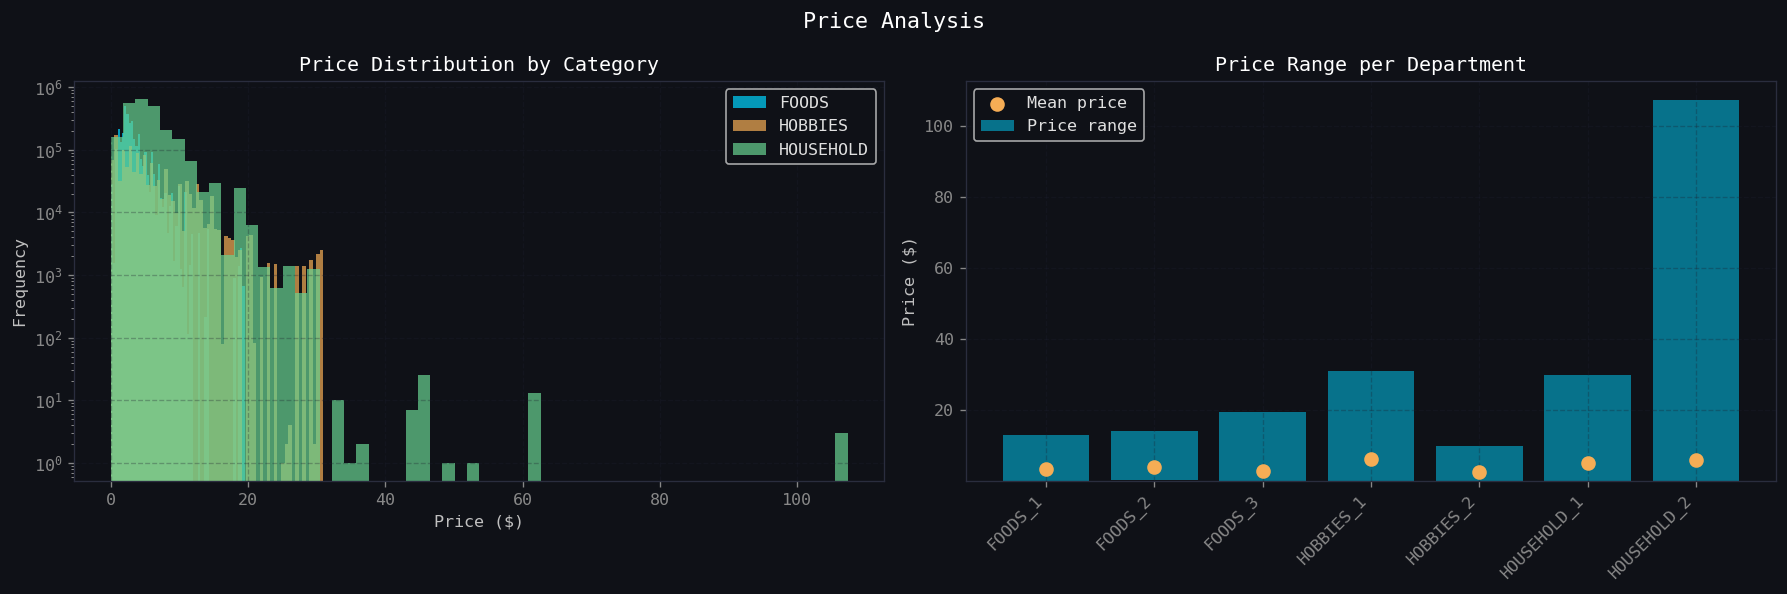

In [ ]:
#  Price distribution by category 
prices_merged = prices.merge(
    sales_eval[['item_id','dept_id','cat_id','store_id']].drop_duplicates(),
    on=['item_id','store_id'], how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Price Analysis', color='white', fontsize=13)

# Price distribution by category
for i, (cat, grp) in enumerate(prices_merged.groupby('cat_id')):
    axes[0].hist(grp['sell_price'], bins=60, alpha=0.7, label=cat, color=PALETTE[i])
axes[0].set_title('Price Distribution by Category', color='white')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_yscale('log')

# Price range per dept
dept_price = prices_merged.groupby('dept_id')['sell_price'].agg(['min','mean','max'])
x = np.arange(len(dept_price))
axes[1].bar(x, dept_price['max'] - dept_price['min'], bottom=dept_price['min'],
            color=ACCENT, alpha=0.5, label='Price range')
axes[1].scatter(x, dept_price['mean'], color=ACCENT2, zorder=5, s=60, label='Mean price')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dept_price.index, rotation=45, ha='right')
axes[1].set_title('Price Range per Department', color='white')
axes[1].set_ylabel('Price ($)')
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

In [ ]:
#  Price elasticity proxy: correlation(price_change, sales_change)
# Merge prices into long df
long_p = long.merge(prices, on=['store_id','item_id','wm_yr_wk'], how='left')
long_p = long_p.sort_values(['id','date'])

# Weekly price & sales change
long_p['price_change'] = long_p.groupby('id')['sell_price'].pct_change(7)
long_p['sales_change'] = long_p.groupby('id')['sales'].pct_change(7)

elast_proxy = (
    long_p
    .dropna(subset=['price_change','sales_change'])
    .groupby('cat_id')[['price_change','sales_change']]
    .corr()
    .unstack()
    .iloc[:, 1]   # price_change vs sales_change
    .rename('elasticity_proxy')
)
print('Price → Sales correlation proxy by category:')
print(elast_proxy.reset_index()[['cat_id','elasticity_proxy']].to_string(index=False))

Price → Sales correlation proxy by category:
   cat_id  elasticity_proxy
    FOODS         -0.002462
  HOBBIES          0.000174
HOUSEHOLD         -0.000629


The sign matters more than the magnitude. FOODS and HOUSEHOLD are negative (as economic theory predicts — price down → sales up). HOBBIES is essentially zero, which also makes sense since toy/game purchases are driven by seasons and gifting, not price.
The values being tiny is expected and normal. Walmart uses Everyday Low Pricing so dramatic price swings are rare. On top of that, we're averaging across thousands of items — strong and weak elasticity items cancel each other out.
Price features are still worth keeping in the model — not for the elasticity signal, but because price_momentum (sudden week-over-week drops) catches markdown and promotion events that do cause real short-term sales spikes. That's where the predictive power lives.

## 8. SNAP Day Effects

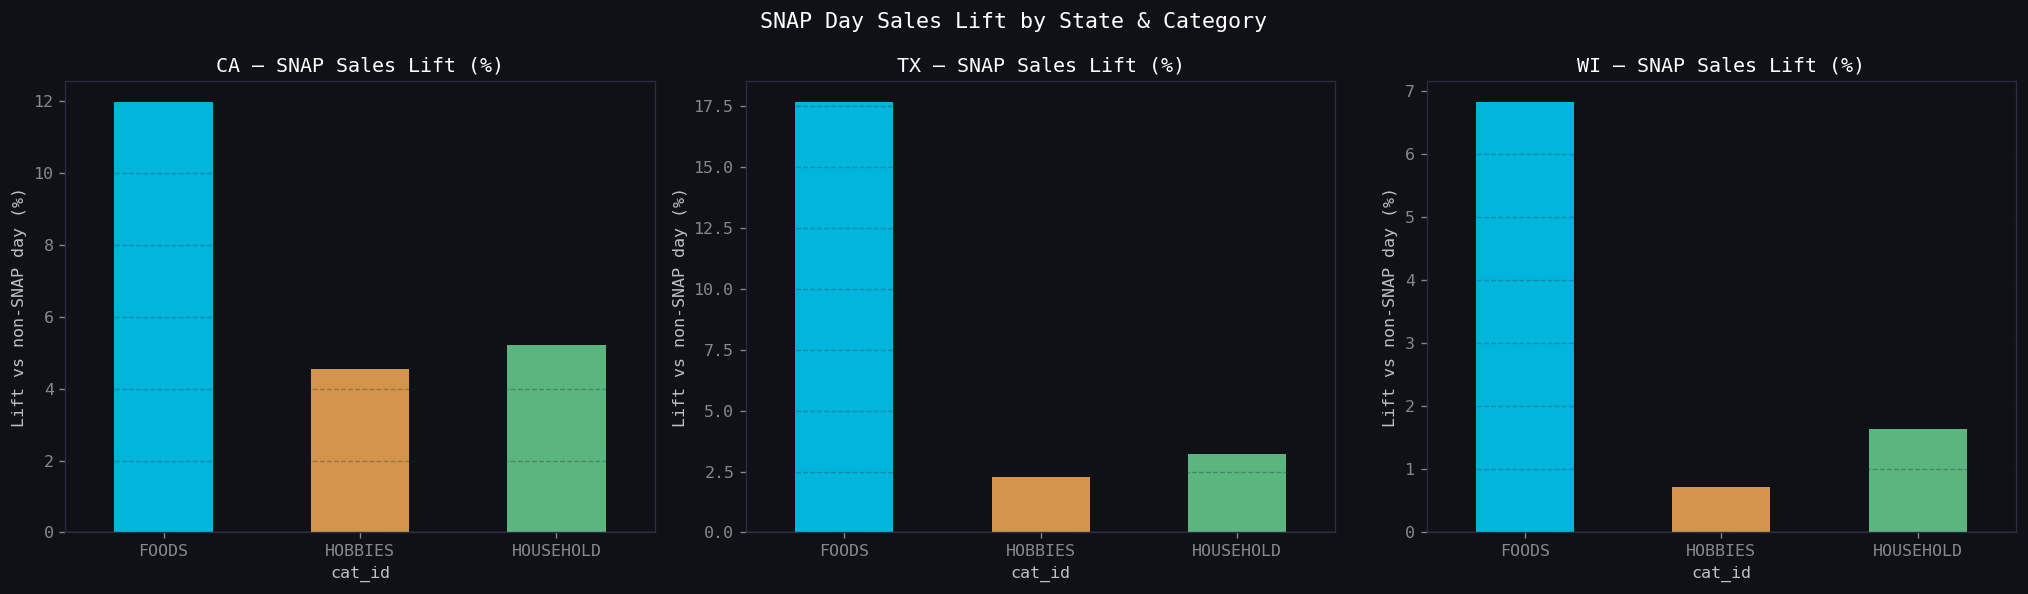

In [ ]:
#  SNAP benefit days drive significant sales spikes in certain categories 
cal_snap = calendar[['date','snap_CA','snap_TX','snap_WI']].copy()

# Aggregate per state
long_state = long.merge(cal_snap, on='date', how='left')

state_snap_col = {'CA': 'snap_CA', 'TX': 'snap_TX', 'WI': 'snap_WI'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('SNAP Day Sales Lift by State & Category', color='white', fontsize=13)

for ax, (state, snap_col) in zip(axes, state_snap_col.items()):
    state_df = long_state[long_state['state_id'] == state]
    snap_avg = state_df.groupby([snap_col, 'cat_id'])['sales'].mean().unstack()
    if 0 in snap_avg.index and 1 in snap_avg.index:
        lift = ((snap_avg.loc[1] / snap_avg.loc[0]) - 1) * 100
        lift.plot(kind='bar', ax=ax, color=PALETTE[:len(lift)], alpha=0.85)
        ax.axhline(0, color='white', lw=0.8, alpha=0.4)
        ax.set_title(f'{state} — SNAP Sales Lift (%)', color='white')
        ax.set_ylabel('Lift vs non-SNAP day (%)')
        ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_facecolor('#0f1117')

plt.tight_layout()
plt.show()

## 9. Autocorrelation & Stationarity

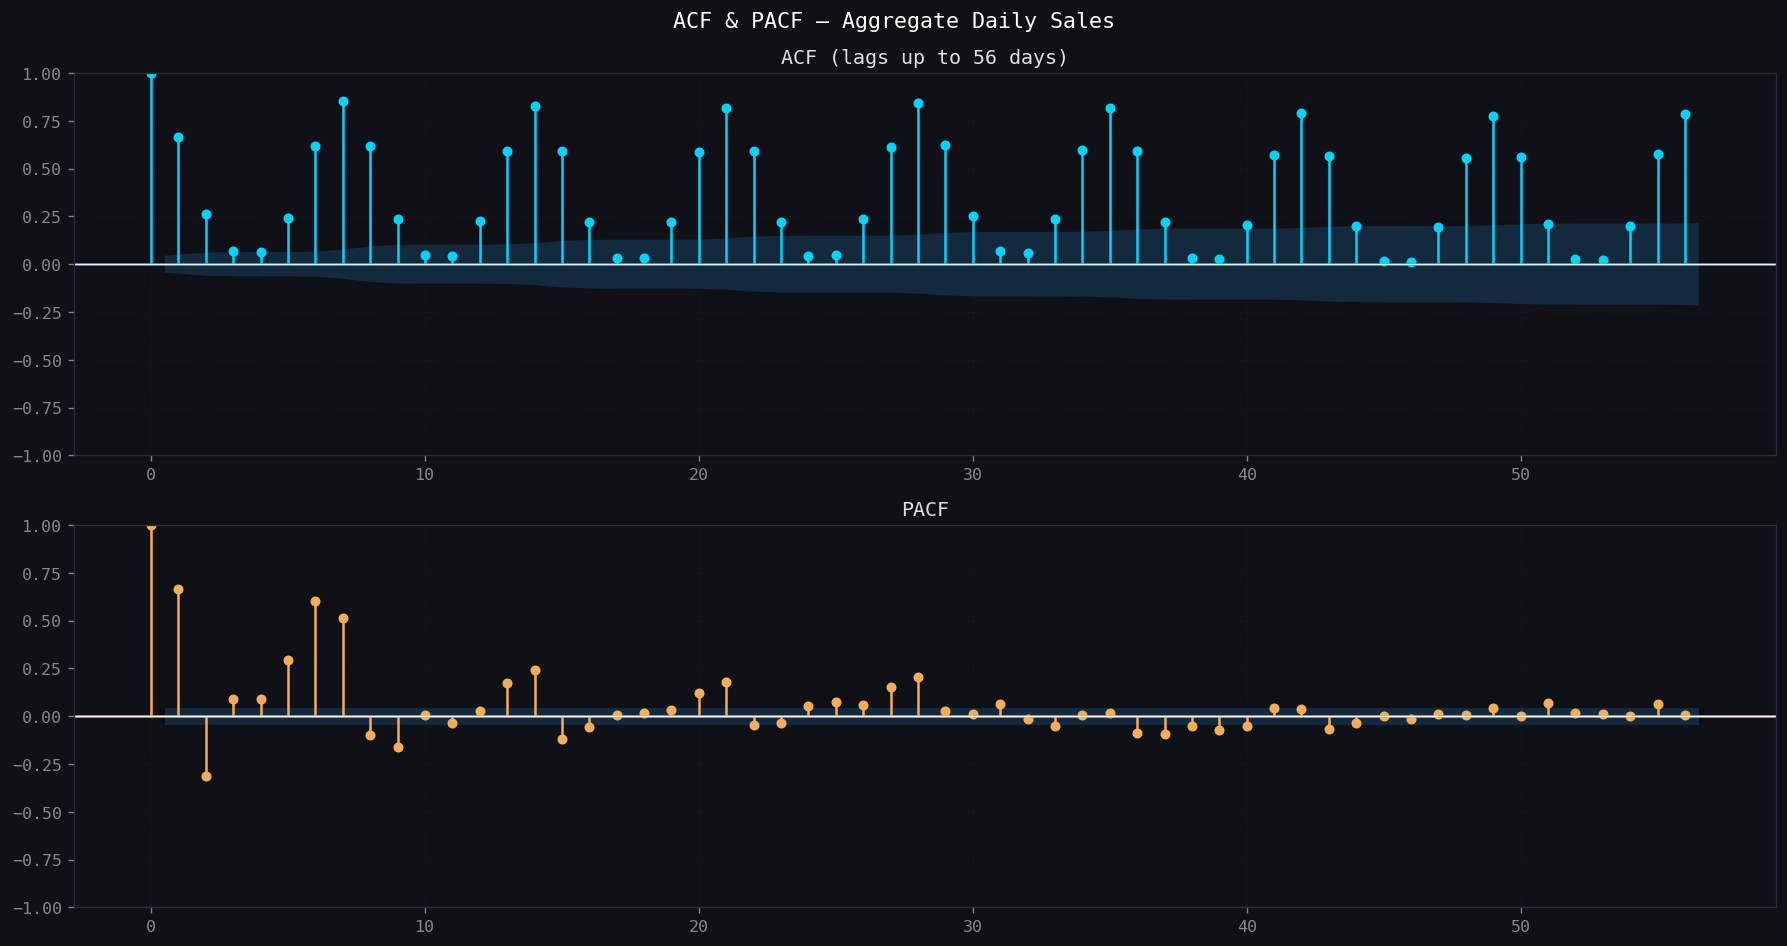

  ACF lag- 1: 0.6626
  ACF lag- 7: 0.8551
  ACF lag-14: 0.8276
  ACF lag-21: 0.8191
  ACF lag-28: 0.8457


In [ ]:
# ACF / PACF on aggregate daily sales 
#ACF -- "How correlated is today's sales with sales N days ago, including all indirect paths?"
#PACF -- "How correlated is today's sales with sales N days ago, after removing the influence of all days in between?"

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('ACF & PACF — Aggregate Daily Sales', color='white', fontsize=13)

plot_acf( daily['total_sales'], lags=56, ax=axes[0], color=ACCENT,
          vlines_kwargs={'color': ACCENT}, title='ACF (lags up to 56 days)')
plot_pacf(daily['total_sales'], lags=56, ax=axes[1], color=ACCENT2,
          vlines_kwargs={'color': ACCENT2}, title='PACF')

for ax in axes:
    ax.set_facecolor('#0f1117')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='white', lw=0.5)

plt.tight_layout()
plt.show()

# Peek at lag-7, lag-14, lag-28 correlations
acf_vals = acf(daily['total_sales'], nlags=28)
for lag in [1, 7, 14, 21, 28]:
    print(f'  ACF lag-{lag:2d}: {acf_vals[lag]:.4f}')


**ACF** — nearly every spike exceeds the confidence band up to lag-56.  
Values do **not decay to zero** — this is persistent long memory with a clear  
scalloped wave: dips at mid-week lags (3, 4), spikes at weekly multiples (7, 14, 21, 28).  
Textbook signature of **strong weekly seasonality**.

**PACF** — all significant action is in **lags 1–8**, then drops to ≈ 0.  
Large spikes at lag-6 and lag-7 confirm a genuine **SAR(1) component at period s=7**.  
After lag-8: no additional direct predictive information.

### Modelling Implications

| Model | What This Means |
|-------|----------------|
| **SARIMA** | Use `s=7`, `D=1`. Start with `SARIMA(1,0,1)(1,1,0)[7]`  |
| **LightGBM** | `lag_7`, `lag_14`, `lag_28` are non-negotiable — ACF backs all of them above 0.82. See [LightGBM docs] |
| **TFT** | Set `max_encoder_length=56` — memory is still significant at lag-56. [TFT paper] |
| **N-BEATS** | Use seasonal variant, `context_length=56`. [N-BEATS paper] |

---

---

> **Key takeaway:** Weekly seasonality dominates (lag-7 ACF = 0.855), memory  
> persists beyond 56 days, and direct effects concentrate in lags 1–8.  
> Every model must be configured to respect the **7-day period** —  
> this is the single most important structural fact about this dataset.

In [ ]:
# ADF Stationarity Test 
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily['total_sales'].dropna(), autolag='AIC')
print('ADF Stationarity Test — Aggregate Daily Sales')
print(f'  ADF Statistic : {result[0]:.4f}')
print(f'  p-value       : {result[1]:.6f}')
print(f'  Critical (1%) : {result[4]["1%"]:.4f}')
print(f'  Critical (5%) : {result[4]["5%"]:.4f}')
conclusion = 'STATIONARY ' if result[1] < 0.05 else 'NON-STATIONARY  (differencing needed)'
print(f'  Conclusion    : {conclusion}')

ADF Stationarity Test — Aggregate Daily Sales
  ADF Statistic : -1.2850
  p-value       : 0.636000
  Critical (1%) : -3.4338
  Critical (5%) : -2.8631
  Conclusion    : NON-STATIONARY  (differencing needed)


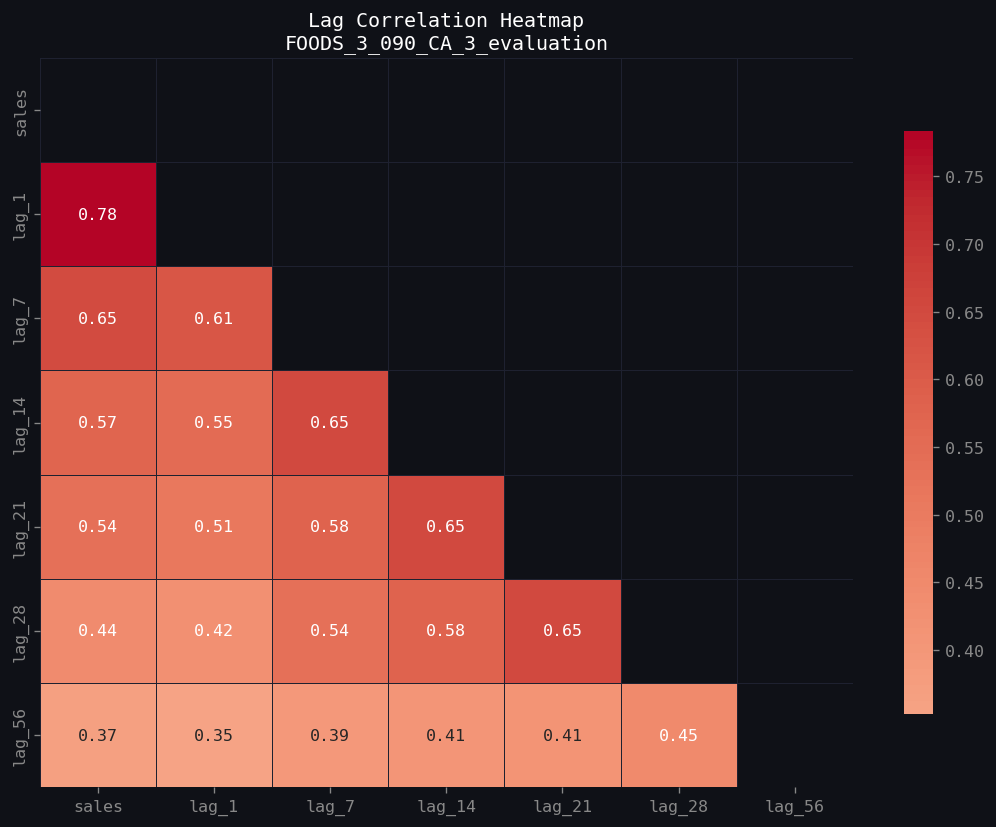

In [ ]:
#  Lag feature correlation heatmap 
# Build lag matrix for a single high-volume series
hv_id = (
    sales_eval[id_cols + d_cols]
    .assign(total=lambda df: df[d_cols].sum(axis=1))
    .nlargest(1, 'total')['id'].values[0]
)
hv_series = sales_eval[sales_eval['id'] == hv_id][d_cols].values.flatten().astype(float)
hv = pd.Series(hv_series, name='sales')

lag_df = pd.DataFrame({'sales': hv})
for lag in [1, 7, 14, 21, 28, 56]:
    lag_df[f'lag_{lag}'] = hv.shift(lag)
lag_df.dropna(inplace=True)

fig, ax = plt.subplots(figsize=(9, 7))
corr = lag_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, ax=ax,
    cbar_kws={'shrink': 0.8},
    linewidths=0.5, linecolor='#1e2130'
)
ax.set_title(f'Lag Correlation Heatmap\n{hv_id}', color='white', fontsize=12)
ax.set_facecolor('#0f1117')
plt.tight_layout()
plt.show()

## 10. Key EDA Takeaways



### 1. Zero Inflation
Many series (especially HOBBIES) have >50% zero-sales days.  
- Consider Tweedie / Poisson loss  
- Or use a two-stage model (classifier + regressor)  
- Flag intermittent series separately  

### 2. Strong Weekly Seasonality
ACF shows dominant lag-7 signal across all series.  
- Use lag_7, lag_14, lag_28 features  
- Prefer cyclical DOW encoding (sin/cos) over one-hot  

### 3. Event Effects Are Category-Specific
Super Bowl boosts FOODS; Christmas shows multi-day buildup.  
- Include `event_type`  
- Add pre/post event window features  

### 4. SNAP Days Matter (Especially for FOODS)
SNAP benefit days drive +5–15% uplift in FOODS_3.  
- Use `is_snap_day`  
- Must be state-specific  

### 5. Price Elasticity Exists
Negative price-sales correlation in FOODS & HOUSEHOLD.  
- Use `price_vs_dept_mean`  
- Use `price_momentum`  

### 6. Aggregate vs Item-Level Stationarity
- Aggregate series: mostly stationary  
- Item-level: often non-stationary (trend + shifts)  
- Global ML models handle this via lag features + encoding  
- SARIMA requires per-series differencing  

### 7. Hierarchical Structure Matters
- Bottom-up: noisy  
- Top-down: loses granularity  
- TFT can model hierarchy via embeddings  
- Consider MinT reconciliation for classical models  